# Compare generators on the Census dataset
This code will automatically gather privacy and utility results to provide an overiew of the generators performances.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import sys
sys.path.append('..')
from tools.utils import get_privacy_summaries
from tools.privacy_results_analysis import load_results, plot_privacy_metrics_multi, plot_spider_matplotlib, COLORS

dataset_records = {
    'census': {
        'vulnerable_records': [565536, 566299, 569481, 266579, 562047, 563075, 558957, 371432, 409552, 511977],
        'random': [50849, 440954, 372936, 250047, 246706, 489178, 48966, 397319, 114785, 53656]
    },
    'adult': {
        'vulnerable_records': [39435, 36838, 6066, 1678, 27566, 43082, 16249, 14731, 5918, 35988],
        'random': [4036, 34999, 29601, 19846, 19581, 38827, 3886, 31536, 9110, 4258]
    }
}

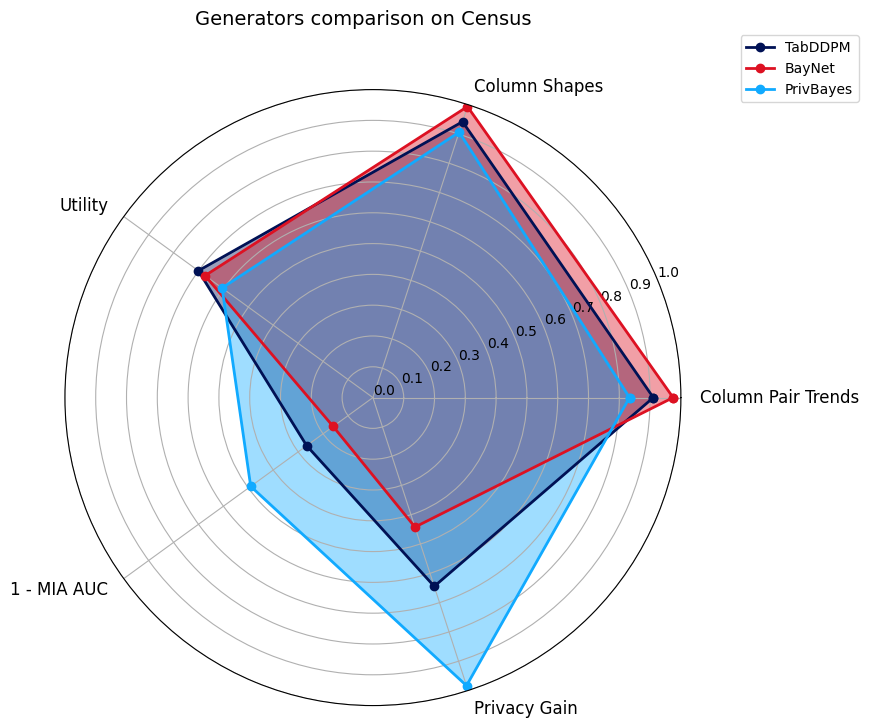

In [2]:
DATASET_ID = 'census'
DATASET_NAME = 'Census' if DATASET_ID == 'census' else 'Adult'
GENERATORS = ['TabDDPM', 'BayNet', 'PrivBayes'] # 'BayNet', , 'BayNetSimple'
RESULTS_PATH = Path('../generated/generators_comparison')
OUTPUT_PATH = Path('../generated/generators_comparison/plots')
LARGE_EXP_INDEX = 30000

privacy_summaries = get_privacy_summaries('../experiments', [DATASET_ID], GENERATORS)
privacy_summaries['record_type'] = privacy_summaries.apply(lambda x: 'vulnerable' if x['target_id'] in dataset_records[DATASET_ID]['vulnerable_records'] else 'random', axis=1)

combined_results = pd.DataFrame()
for generator in GENERATORS:
    combined_results = pd.concat([combined_results, load_results(generator, privacy_summaries, RESULTS_PATH, DATASET_ID, LARGE_EXP_INDEX, dataset_records)])

concat_name = '_'.join(GENERATORS)
plot_spider_matplotlib(combined_results, DATASET_NAME, pdf_path=OUTPUT_PATH / f'{DATASET_ID}_{concat_name}.pdf')

In [3]:
# combined_results[['Utility', 'Column Shapes', 'Column Pair Trends', '1 - MIA AUC', '1 - MIA AUC VR', '1 - MIA AUC RR']].astype(float).round(3)

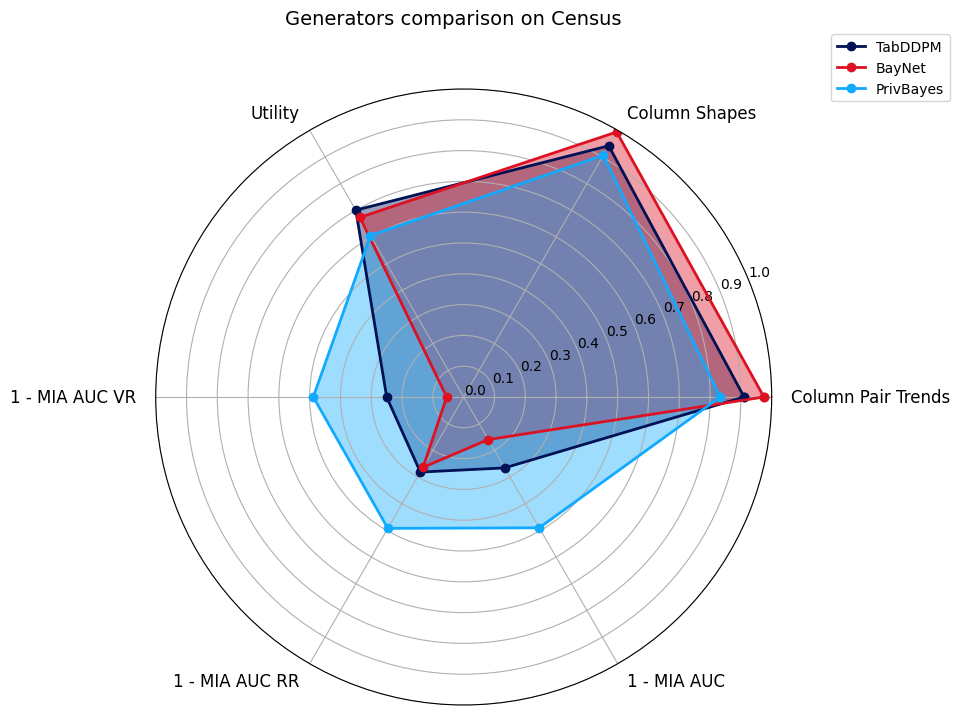

In [4]:
combined_results = pd.DataFrame()
for generator in GENERATORS:
    combined_results = pd.concat([combined_results, load_results(generator, privacy_summaries, RESULTS_PATH, DATASET_ID, LARGE_EXP_INDEX, dataset_records, True)])

color_mapper: dict = {'TabDDPM': 0, 'BayNet': 1, 'PrivBayes': 2}
concat_name = '_'.join(GENERATORS)
plot_spider_matplotlib(combined_results, DATASET_NAME, pdf_path=OUTPUT_PATH / f'{DATASET_ID}_{concat_name}_full.pdf', color_mapper=color_mapper)

In [5]:
combined_results[['Utility', 'Column Shapes', 'Column Pair Trends', '1 - MIA AUC', '1 - MIA AUC VR', '1 - MIA AUC RR']].astype(float).round(3)

,Utility,Column Shapes,Column Pair Trends,1 - MIA AUC,1 - MIA AUC VR,1 - MIA AUC RR
TabDDPM,0.701,0.942,0.910,0.266,0.250,0.281
BayNet,0.674,0.993,0.975,0.160,0.055,0.264
PrivBayes,0.605,0.906,0.833,0.490,0.488,0.492


/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/3474070039.py:3: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Utility',
/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/3474070039.py:3: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Utility',


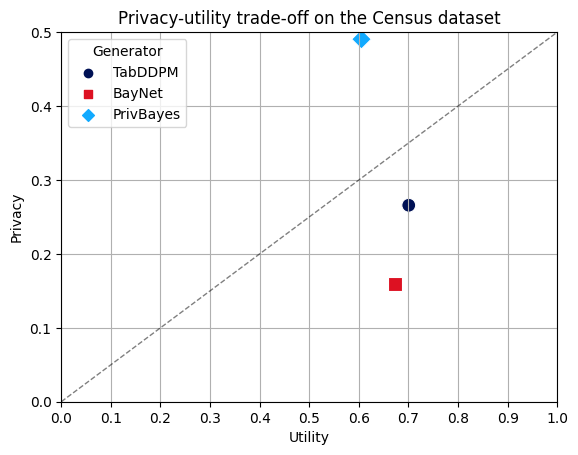

In [6]:
# plot 1-MIA AUC VR and Utility a scatter plot combined_results
# don't use dots but the generator name as the marker
sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Utility', 
                hue=combined_results.index, palette=COLORS, s=100, style=combined_results.index,
                markers=['o', 's', 'D', '^'])
plt.ylabel('Privacy')
plt.xlabel('Utility')
# both axes between 0 and 1
plt.xlim(0, 1)
plt.ylim(0, 0.5)
plt.xticks(np.arange(0, 1.1, 0.1))

# plot a line from 0,0 to 0.5, 1
plt.plot([0, 1], [0, 0.5], 'k--', lw=1, alpha=0.5)
plt.grid(True)
plt.legend(title='Generator')
plt.title(f'Privacy-utility trade-off on the {DATASET_NAME} dataset')
plt.show()

/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/2410206083.py:3: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Column Pair Trends',
/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/2410206083.py:3: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Column Pair Trends',
/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/2410206083.py:7: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Column Shapes',
/var/folders/mb/y8_byc0x1fl80yvxkf612cmm0000gp/T/ipykernel_25668/2410206083.py:7: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.scatterplot(data=combined_results, y='1 - MIA AUC

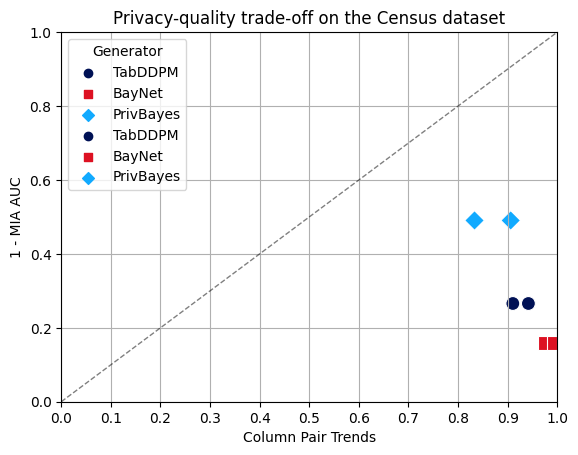

In [7]:
# plot 1-MIA AUC VR and Utility a scatter plot combined_results
# don't use dots but the generator name as the marker
sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Column Pair Trends', 
                hue=combined_results.index, palette=COLORS, s=100, style=combined_results.index,
                markers=['o', 's', 'D', '^'])
# also plot the column shapes
sns.scatterplot(data=combined_results, y='1 - MIA AUC', x='Column Shapes', 
                hue=combined_results.index, palette=COLORS, s=100, style=combined_results.index,
                markers=['o', 's', 'D', '^'])
# both axes between 0 and 1
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

# plot a line from 0,0 to 0.5, 1
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.grid(True)
plt.legend(title='Generator')
plt.title(f'Privacy-quality trade-off on the {DATASET_NAME} dataset')
plt.show()

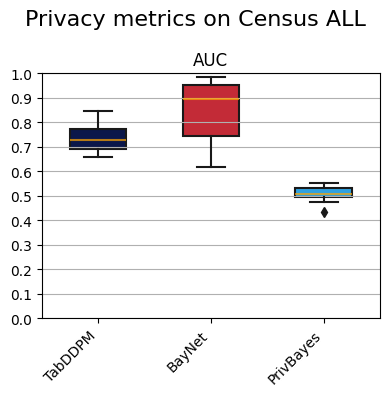

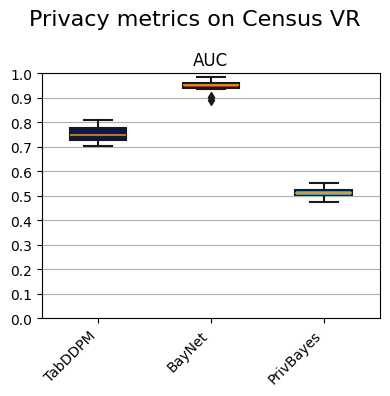

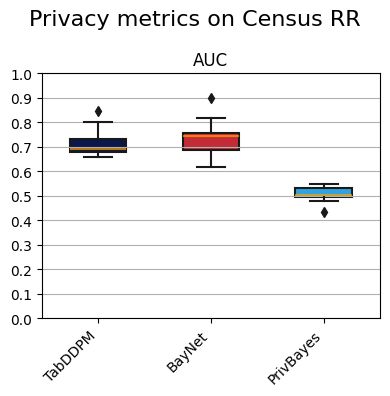

In [16]:
# sort according to the generator from GENERATORS and on record_type (vulnerable first)
privacy_summaries['generator'] = pd.Categorical(privacy_summaries['generator'], GENERATORS)
privacy_summaries['record_type'] = pd.Categorical(privacy_summaries['record_type'], ['vulnerable', 'random'])
privacy_summaries = privacy_summaries.sort_values(['generator', 'record_type'])

plot_privacy_metrics_multi(privacy_summaries, f"Privacy metrics on {DATASET_NAME} ALL", metrics=['auc'])
plot_privacy_metrics_multi(privacy_summaries[privacy_summaries['record_type'] == 'vulnerable'], f"Privacy metrics on {DATASET_NAME} VR", metrics=['auc'])
plot_privacy_metrics_multi(privacy_summaries[privacy_summaries['record_type'] == 'random'], f"Privacy metrics on {DATASET_NAME} RR", metrics=['auc'])

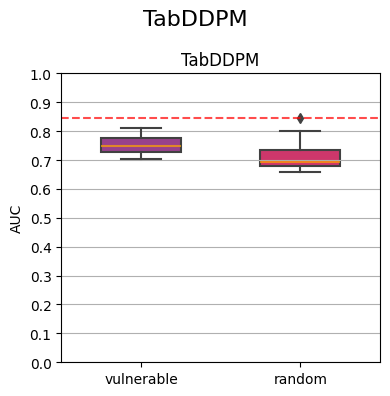

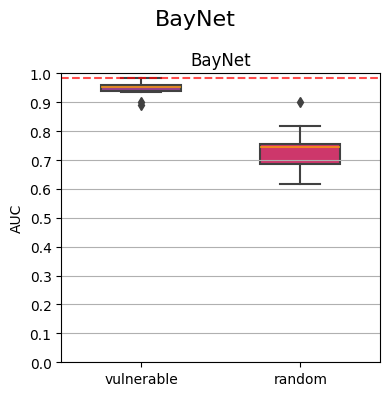

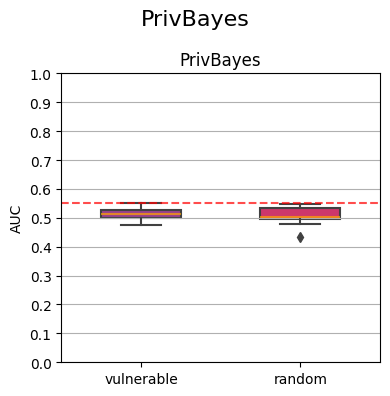

In [21]:
# Compare random vs mvr for both approaches
for generator in GENERATORS:
    plot_privacy_metrics_multi(privacy_summaries[privacy_summaries['generator']==generator], f"{generator}", 
                            x='record_type', color_palette=COLORS[len(GENERATORS):], metrics=['auc'])

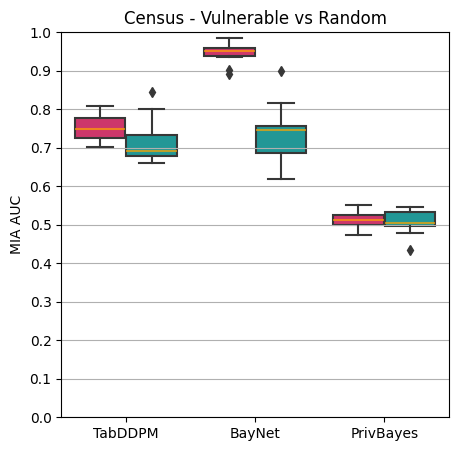

In [75]:
# plot the auc of every generator side by side, without using previous functions
plt.figure(figsize=(5, 5))
# make the boxplot such that each generator is side by side, with the record type as the hue
sns.boxplot(data=privacy_summaries, x='generator', y='auc', hue='record_type',  palette=COLORS[4:], width=.8, medianprops=dict(color="orange", alpha=0.7))
plt.ylabel('MIA AUC')
plt.xlabel('')
# set yacis between 0 and 1
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))

# do not show the legend
plt.legend().remove()

plt.grid(axis='y')
plt.title(f'{DATASET_NAME} - Vulnerable vs Random')
# export to AUC on census.pdf
plt.savefig(OUTPUT_PATH / f'{DATASET_ID}_auc_random_vulnerable.pdf', bbox_inches='tight', format='pdf')
plt.show()

In [84]:
privacy_summaries[(privacy_summaries['generator']=='TabDDPM')].sort_values('auc', ascending=False)

,dataset,target_id,generator,attack,accuracy,true_positive_rate,false_positive_rate,mia_advantage,privacy_gain,auc,effective_epsilon,threat_model,timestamp,record_type,gen_record
58,census,489178,TabDDPM,ah,0.750,0.75,0.25,0.50,0.50,0.8454,3.135494,aux-bb-mia,20250215-175422,random,TabDDPM - random
44,census,409552,TabDDPM,ah,0.745,0.69,0.20,0.49,0.51,0.8093,inf,aux-bb-mia,20250216-195440,vulnerable,TabDDPM - vulnerable
45,census,440954,TabDDPM,ah,0.715,0.67,0.24,0.43,0.57,0.8019,inf,aux-bb-mia,20250214-023449,random,TabDDPM - random
49,census,569481,TabDDPM,ah,0.720,0.64,0.20,0.44,0.56,0.7838,2.484907,aux-bb-mia,20250214-112817,vulnerable,TabDDPM - vulnerable
41,census,563075,TabDDPM,ah,0.695,0.64,0.25,0.39,0.61,0.7803,inf,aux-bb-mia,20250215-153758,vulnerable,TabDDPM - vulnerable
42,census,266579,TabDDPM,ah,0.715,0.69,0.26,0.43,0.57,0.7680,2.197225,aux-bb-mia,20250214-204958,vulnerable,TabDDPM - vulnerable
54,census,371432,TabDDPM,ah,0.720,0.65,0.21,0.44,0.56,0.7519,1.586965,aux-bb-mia,20250216-102511,vulnerable,TabDDPM - vulnerable
47,census,566299,TabDDPM,ah,0.705,0.69,0.28,0.41,0.59,0.7469,3.178054,aux-bb-mia,20250214-020614,vulnerable,TabDDPM - vulnerable
57,census,53656,TabDDPM,ah,0.680,0.76,0.40,0.36,0.64,0.7380,2.397895,aux-bb-mia,20250217-092602,random,TabDDPM - random
40,census,511977,TabDDPM,ah,0.670,0.62,0.28,0.34,0.66,0.7264,inf,aux-bb-mia,20250217-052529,vulnerable,TabDDPM - vulnerable


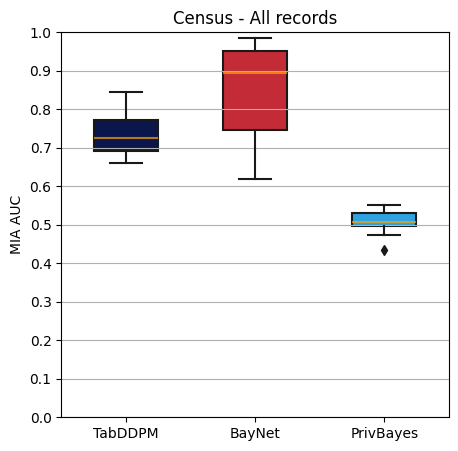

In [77]:
plt.figure(figsize=(5, 5))
# make the boxplot such that each generator is side by side, with the record type as the hue
sns.boxplot(data=privacy_summaries, x='generator', y='auc',  palette=COLORS, width=.5, medianprops=dict(color="orange", alpha=0.7))
plt.ylabel('MIA AUC')
plt.xlabel('')
# set yacis between 0 and 1
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1.1, 0.1))
# horizontal grid
plt.grid(axis='y')
plt.title(f'{DATASET_NAME} - All records')
# export to AUC on census.pdf
plt.savefig(OUTPUT_PATH / f'{DATASET_ID}_auc_all.pdf', bbox_inches='tight', format='pdf')
plt.show()

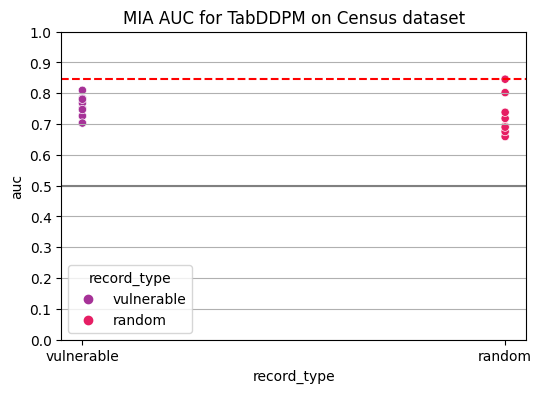

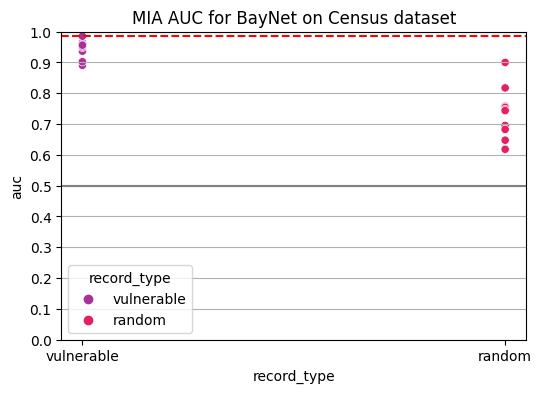

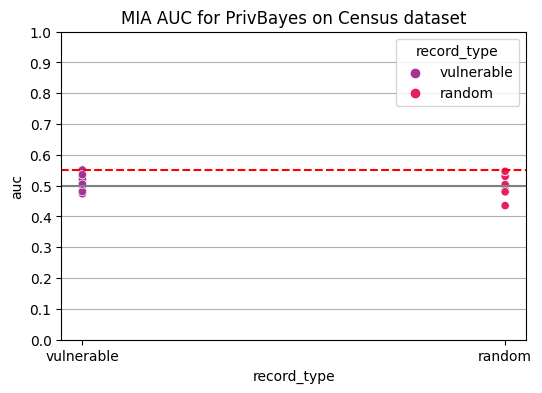

In [14]:
for generator in GENERATORS:
    gen_summaries = privacy_summaries[privacy_summaries['generator'] == generator].copy()
    gen_summaries['record_type'] = pd.Categorical(gen_summaries['record_type'], ['vulnerable', 'random'])
    gen_summaries = gen_summaries.sort_values('record_type')

    # small fig size
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=gen_summaries, x='record_type', y='auc', hue='record_type', palette=COLORS[len(GENERATORS):len(GENERATORS)+2])
    plt.ylim(0, 1)
    # plot every 0.1 in y
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.grid(True, axis='y')
    # put the 0.5 line in light grey, but make it not ugly with the grid
    plt.axhline(y=0.5, color='grey', linestyle='-')
    plt.title(f"MIA AUC for {generator} on Census dataset")
    # add a horizontal line at the maximal value
    plt.axhline(y=gen_summaries['auc'].max(), color='r', linestyle='--')
    plt.show()